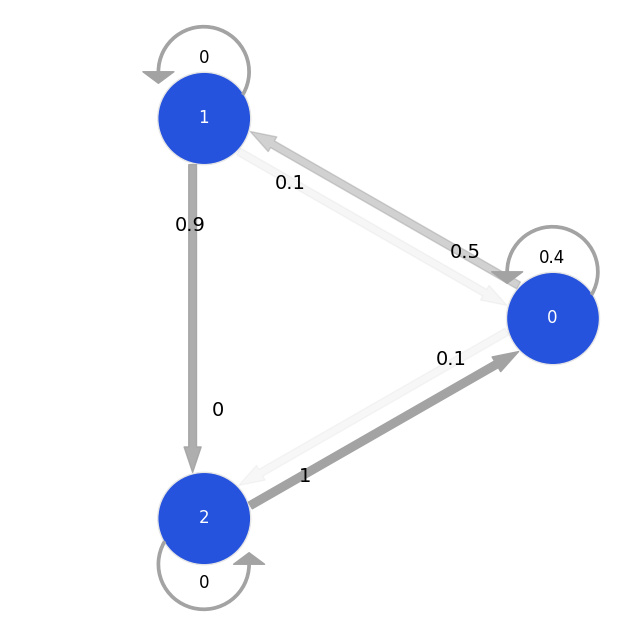

Skewed Transition Matrix P (for each action and state):
[[[0.427 0.492 0.08 ]
  [0.093 0.028 0.879]
  [0.998 0.002 0.   ]]

 [[0.36  0.174 0.466]
  [0.    0.087 0.913]
  [1.    0.    0.   ]]

 [[0.067 0.329 0.604]
  [0.007 0.146 0.846]
  [1.    0.    0.   ]]]

Sparse and Skewed Reward Function R:
[2 3 9]


In [63]:
import numpy as np
import matplotlib.pyplot as plt
from markovchain import MarkovChain

# Define the MDP with transition matrix, rewards, etc.
n_S = 3  # Number of states
n_A = 3  # Number of actions
R_max = 10  # Maximum reward value

S = np.arange(n_S)  # State space
A = np.arange(n_A)  # Action space

# Skewed transition matrix to make it extremely hard to reach high-reward states
P = np.zeros((n_A, n_S, n_S))
for a in range(n_A):
    for s in range(n_S):
        # If state s = 2 (the high-reward state), make it almost unreachable
        if s == 2:
            skew_param = [0.9, 0.09, 0.01]  # Very low probability of reaching state 2
        else:
            skew_param = [0.2, 0.3, 0.5]  # Other states are easier to transition between
        P[a, s, :] = np.random.dirichlet(skew_param)

# Sparse and skewed rewards: high rewards are given, but state 2 is very hard to reach
R = np.array([2, 3, 9])  # State 2 has the highest reward but is very difficult to access

# Discount factor
gamma = 0.9

# Define the MDP as a tuple
MDP = (S, A, P, R, gamma)

# Visualize the Markov Chain using MarkovChain library
mc = MarkovChain(P[0], list(map(str, S)))  # Use P[0] as an example (since the matrix is n_A x n_S)
mc.draw()

# Print the skewed transition matrix and reward function
print("Skewed Transition Matrix P (for each action and state):")
print(P)

print("\nSparse and Skewed Reward Function R:")
print(R)


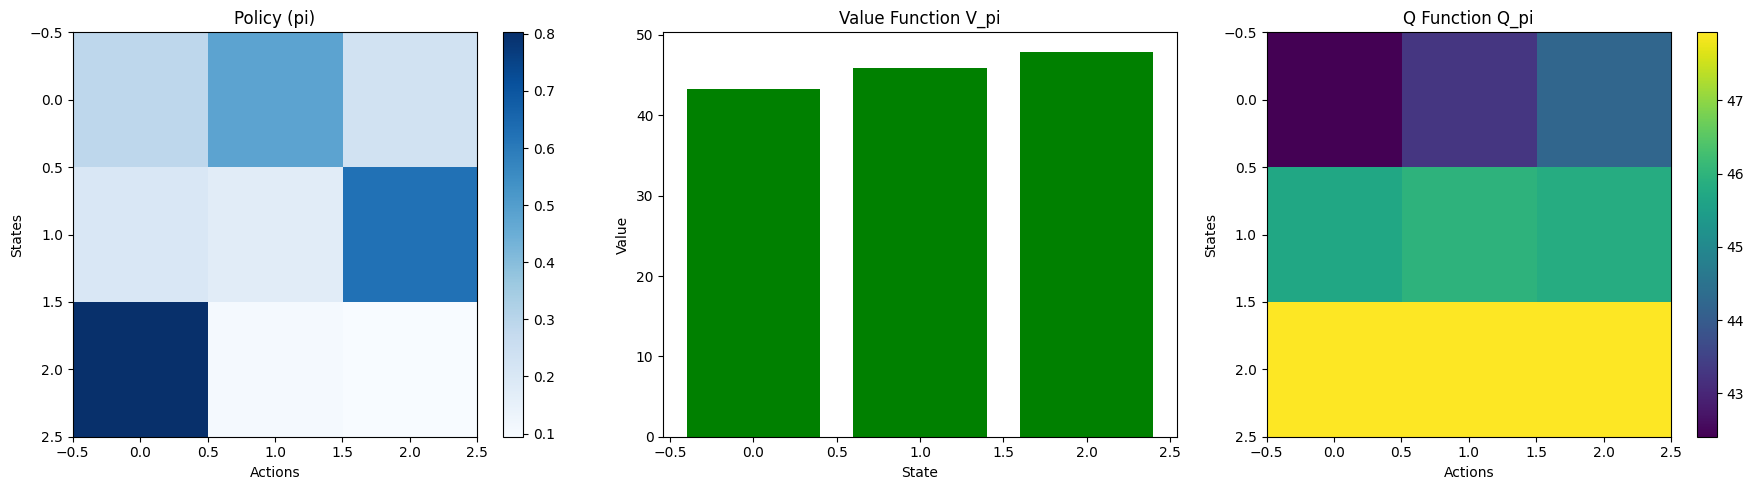

In [64]:

# Define a random stochastic policy (probability distribution over actions for each state)
pi = np.random.dirichlet(np.ones(n_A), size=n_S)

# Compute value function for a given policy pi and MDP
def value_function_given_policy(MDP, pi, tol=1e-6):  # Computes V_pi for given policy
    S, A, P, R, gamma = MDP  # Unpack MDP tuple
    V_pi = np.zeros(len(S))
    while True:
        V_new = np.zeros(len(S))
        for s in range(len(S)):
            V_new[s] = sum(pi[s, a] * (R[s] + gamma * np.dot(P[a, s, :], V_pi)) for a in range(len(A)))  # Corrected to use dot product
        if np.max(np.abs(V_new - V_pi)) < tol:
            break
        V_pi = V_new
    return V_pi

# Compute Q-function for a given policy pi and MDP
def q_function_given_policy(MDP, V_pi):  # Computes Q_pi based on V_pi
    S, A, P, R, gamma = MDP  # Unpack MDP tuple
    Q_pi = np.zeros((len(S), len(A)))
    for s in range(len(S)):
        for a in range(len(A)):
            Q_pi[s, a] = R[s] + gamma * np.dot(P[a, s, :], V_pi)  # Corrected to use dot product
    return Q_pi

# Visualization: pi, V_pi, and Q_pi in a 1x3 grid
def plot_policy_v_q(pi, V_pi, Q_pi):  # Plot the policy, V_pi, and Q_pi in a grid
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # Plot the policy pi as a grid
    im1 = ax1.imshow(pi, cmap="Blues")
    ax1.set_title("Policy (pi)")
    ax1.set_xlabel("Actions")
    ax1.set_ylabel("States")
    plt.colorbar(im1, ax=ax1)

    # Plot the value function V_pi as a bar plot
    ax2.bar(range(len(V_pi)), V_pi, color='green')
    ax2.set_title("Value Function V_pi")
    ax2.set_xlabel("State")
    ax2.set_ylabel("Value")

    # Plot the Q-function Q_pi as a grid
    im2 = ax3.imshow(Q_pi, cmap="viridis")
    ax3.set_title("Q Function Q_pi")
    ax3.set_xlabel("Actions")
    ax3.set_ylabel("States")
    plt.colorbar(im2, ax=ax3)

    plt.tight_layout()
    plt.show()

# Compute the value function and Q-function for the given policy
V_pi = value_function_given_policy(MDP, pi)
Q_pi = q_function_given_policy(MDP, V_pi)

# Plot the policy, value function, and Q-function
plot_policy_v_q(pi, V_pi, Q_pi)

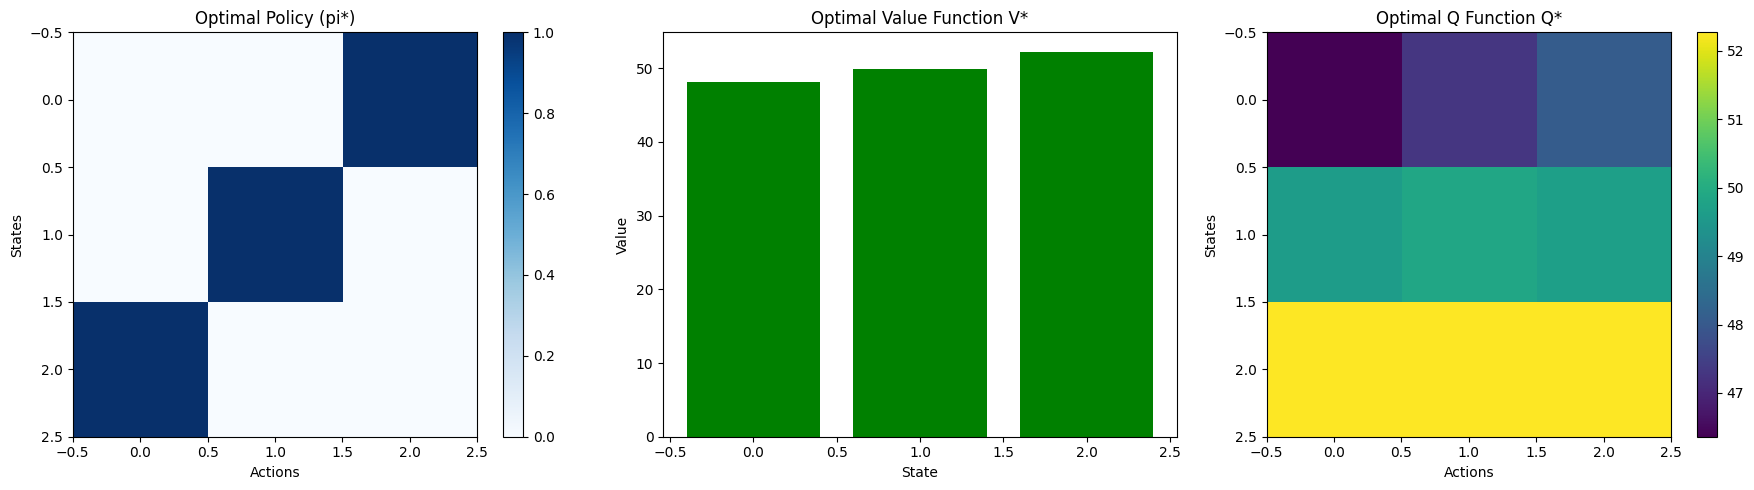

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Refactored Value Iteration Function
def value_iteration(MDP, tol=1e-6):  # Computes V* using value iteration
    S, A, P, R, gamma = MDP  # Unpack MDP tuple
    V_star = np.zeros(len(S))

    while True:
        V_new = np.zeros(len(S))
        for s in range(len(S)):
            # Maximize over actions for each state
            V_new[s] = max(R[s] + gamma * np.dot(P[a, s, :], V_star) for a in range(len(A)))  # Dot product to get the expected reward for each action
        
        if np.max(np.abs(V_new - V_star)) < tol:
            break
        V_star = V_new

    return V_star

# Compute the Optimal Policy based on V*
def optimal_policy(MDP, V_star):  # Computes the optimal policy pi* and Q* using V*
    S, A, P, R, gamma = MDP  # Unpack MDP tuple
    Q_star = np.zeros((len(S), len(A)))
    pi_star = np.zeros((len(S), len(A)))  # Optimal policy

    for s in range(len(S)):
        for a in range(len(A)):
            Q_star[s, a] = R[s] + gamma * np.dot(P[a, s, :], V_star)  # Dot product to compute Q*

        # Choose the action with the highest Q-value for each state
        best_action = np.argmax(Q_star[s])
        pi_star[s, :] = np.eye(len(A))[best_action]  # Deterministic policy: only the best action has probability 1

    return pi_star, Q_star

# Plot the Optimal Policy, V_star, and Q_star
def plot_optimal_policy_v_q(pi_star, V_star, Q_star):  # Plot the optimal pi*, V*, and Q* in a grid
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # Plot the optimal policy pi_star as a grid
    im1 = ax1.imshow(pi_star, cmap="Blues")
    ax1.set_title("Optimal Policy (pi*)")
    ax1.set_xlabel("Actions")
    ax1.set_ylabel("States")
    plt.colorbar(im1, ax=ax1)

    # Plot the optimal value function V_star as a bar plot
    ax2.bar(range(len(V_star)), V_star, color='green')
    ax2.set_title("Optimal Value Function V*")
    ax2.set_xlabel("State")
    ax2.set_ylabel("Value")

    # Plot the optimal Q-function Q_star as a grid
    im2 = ax3.imshow(Q_star, cmap="viridis")
    ax3.set_title("Optimal Q Function Q*")
    ax3.set_xlabel("Actions")
    ax3.set_ylabel("States")
    plt.colorbar(im2, ax=ax3)

    plt.tight_layout()
    plt.show()

# Compute V_star using value iteration
V_star = value_iteration(MDP)

# Compute the optimal policy pi_star and optimal Q-function Q_star
pi_star, Q_star = optimal_policy(MDP, V_star)

# Plot the optimal policy, V_star, and Q_star
plot_optimal_policy_v_q(pi_star, V_star, Q_star)


In [67]:
import numpy as np
import itertools

# Define the MDP with transition matrix, rewards, etc.
n_S = 3  # Number of states
n_A = 3  # Number of actions
R_max = 10  # Maximum reward value

S = np.arange(n_S)  # State space
A = np.arange(n_A)  # Action space

# Skewed transition matrix to make it harder to reach high-reward states
P = np.zeros((n_A, n_S, n_S))
for a in range(n_A):
    for s in range(n_S):
        if s == 2:  # High-reward state
            skew_param = [0.6, 0.3, 0.1]
        else:
            skew_param = [0.2, 0.3, 0.5]
        P[a, s, :] = np.random.dirichlet(skew_param)

# Discount factor
gamma = 0.99

# Define the MDP as a tuple (without rewards)
MDP = (S, A, P, gamma)

# Coarse discretization of rewards: e.g., rewards [0, 2.5, 5, 7.5, 10]
def discretize_rewards(R_max, num_steps):
    return np.linspace(0, R_max, num_steps)

# Generate all combinations of reward vectors
def generate_reward_combinations(n_S, R_max, num_steps):
    reward_grid = discretize_rewards(R_max, num_steps)
    return list(itertools.product(reward_grid, repeat=n_S))

# Check if a reward vector is compatible with the MDP
def is_reward_compatible(MDP, R, tol=1e-6):
    S, A, P, gamma = MDP
    V_pi = np.zeros(len(S))  # Initialize value function

    # Run a few iterations of value updates to check if the reward is compatible
    for _ in range(100):
        V_new = np.zeros(len(S))
        for s in range(len(S)):
            # Simulate a simple policy where the agent takes any action randomly
            V_new[s] = max(R[s] + gamma * np.dot(P[a, s, :], V_pi) for a in range(len(A)))

        if np.max(np.abs(V_new - V_pi)) < tol:  # Converged
            break
        V_pi = V_new

    # Here we simply check if the resulting value function has reasonable values
    return np.all(V_pi >= 0)

# Search for compatible and incompatible reward vectors
def search_compatible_rewards(MDP, R_max, num_steps):
    reward_combinations = generate_reward_combinations(len(MDP[0]), R_max, num_steps)
    compatible_rewards = []
    incompatible_rewards = []

    for R in reward_combinations:
        if is_reward_compatible(MDP, np.array(R)):
            compatible_rewards.append(R)
        else:
            incompatible_rewards.append(R)

    return compatible_rewards, incompatible_rewards

# Set the number of discretization steps
num_steps = 10  # Coarse discretization, e.g., [0, 2.5, 5, 7.5, 10]

# Search for compatible and incompatible reward vectors
compatible_rewards, incompatible_rewards = search_compatible_rewards(MDP, R_max, num_steps)

# Print the results
print("Compatible Reward Vectors:")
for i in compatible_rewards:
    print(i)

print("\nIncompatible Reward Vectors:")
for i in incompatible_rewards:
    print(i)


Compatible Reward Vectors:
(0.0, 0.0, 0.0)
(0.0, 0.0, 1.1111111111111112)
(0.0, 0.0, 2.2222222222222223)
(0.0, 0.0, 3.3333333333333335)
(0.0, 0.0, 4.444444444444445)
(0.0, 0.0, 5.555555555555555)
(0.0, 0.0, 6.666666666666667)
(0.0, 0.0, 7.777777777777779)
(0.0, 0.0, 8.88888888888889)
(0.0, 0.0, 10.0)
(0.0, 1.1111111111111112, 0.0)
(0.0, 1.1111111111111112, 1.1111111111111112)
(0.0, 1.1111111111111112, 2.2222222222222223)
(0.0, 1.1111111111111112, 3.3333333333333335)
(0.0, 1.1111111111111112, 4.444444444444445)
(0.0, 1.1111111111111112, 5.555555555555555)
(0.0, 1.1111111111111112, 6.666666666666667)
(0.0, 1.1111111111111112, 7.777777777777779)
(0.0, 1.1111111111111112, 8.88888888888889)
(0.0, 1.1111111111111112, 10.0)
(0.0, 2.2222222222222223, 0.0)
(0.0, 2.2222222222222223, 1.1111111111111112)
(0.0, 2.2222222222222223, 2.2222222222222223)
(0.0, 2.2222222222222223, 3.3333333333333335)
(0.0, 2.2222222222222223, 4.444444444444445)
(0.0, 2.2222222222222223, 5.555555555555555)
(0.0, 2.222222

In [69]:
import numpy as np
import scipy.linalg
from scipy.optimize import linprog

# Define the MDP with transition matrix, rewards, etc.
n_S = 3  # Number of states
n_A = 3  # Number of actions
R_max = 10  # Maximum reward value

S = np.arange(n_S)  # State space
A = np.arange(n_A)  # Action space

# Skewed transition matrix to make it harder to reach high-reward states
P = np.zeros((n_A, n_S, n_S))
for a in range(n_A):
    for s in range(n_S):
        if s == 2:  # High-reward state
            skew_param = [0.6, 0.3, 0.1]  # Low probability of reaching this state
        else:
            skew_param = [0.2, 0.3, 0.5]  # Easier to transition to lower-reward states
        P[a, s, :] = np.random.dirichlet(skew_param)

# Discount factor
gamma = 0.99

# Placeholder for policy pi (e.g., greedy policy where action 0 is always optimal)
pi_star = np.eye(n_A)[0]  # Optimal action is action 0

# Define the MDP without rewards (we will solve for rewards using IRL)
MDP = (S, A, P, gamma)

# Objective: maximize Q(s, a1) - max_a Q(s, a) with a penalty term for ||R||_1
def irl_lp_formulation(MDP, pi_star, R_max, lambda_penalty=1.0):
    S, A, P, gamma = MDP
    n_states = len(S)

    # Set up the linear programming (LP) problem
    # The decision variables will be the rewards R(s) for each state s

    # Objective function: maximize Q(s, a1) - max_a Q(s, a)
    # We are maximizing a difference, so we can set this as a minimization problem
    c = np.zeros(n_states)  # Initialize the objective for R(s)
    
    # For each state, we need to compute the difference between Q(s, a1) and Q(s, a2, a3)
    for s in range(n_states):
        # Calculate (I - gamma * P_a1)^-1 for the optimal action a1
        inv_matrix_a1 = np.linalg.inv(np.eye(n_states) - gamma * P[0])
        
        # Difference between optimal action a1 and other actions
        for a in range(1, n_A):  # Non-optimal actions
            Pa_diff = P[0, s, :] - P[a, s, :]
            Q_diff = np.dot(Pa_diff, inv_matrix_a1)
            
            # Adjust the objective to reflect this difference
            c[s] -= np.sum(Q_diff)

    # Add L1 penalty term for ||R||_1 (simpler rewards)
    # This makes it prefer sparse rewards by penalizing large reward values
    penalty = lambda_penalty * np.ones(n_states)
    c += penalty

    # Constraints: (P_a1 - P_a)(I - gamma * P_a1)^-1 * R >= 0
    A_ub = []  # Upper bound inequality constraints
    b_ub = []  # Corresponding right-hand side for inequalities

    for a in range(1, n_A):  # Loop over non-optimal actions
        Pa_diff = P[0] - P[a]  # P_a1 - P_a
        constraint_matrix = np.dot(Pa_diff, inv_matrix_a1)

        for s in range(n_states):
            A_ub.append(-constraint_matrix[s])  # Add as inequality (negative)
            b_ub.append(0)  # Corresponding right-hand side is 0

    A_ub = np.vstack(A_ub)
    b_ub = np.array(b_ub)

    # Bounds: R(s) between 0 and R_max
    bounds = [(0, R_max) for _ in range(n_states)]

    # Solve the linear program
    result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

    if result.success:
        return result.x  # Return the optimal reward function R
    else:
        raise ValueError("LP solver did not converge")

# Solve the LP problem to find the optimal reward function
optimal_R = irl_lp_formulation(MDP, pi_star, R_max)

# Print the result
print("Optimal Reward Function R:")
print(optimal_R)


Optimal Reward Function R:
[0. 0. 0.]
